In [1]:
#Source:https://matplotlib.org/stable/users/explain/axes/colorbar_placement.html#colorbar-placement 

Colorbars indicate the quantitative extent of image data. Placing in a figure is non-trivial because room needs to be made for them.

<h2>Automatic placement of colorbars</h2>
The simplest case is just attaching a colorbar to each Axes. Note in this example that the colorbars steal some space from the parent Axes.

The first column has the same type of data in both rows, so it may be desirable to have just one colorbar. We do this by passing Figure.colorbar a list of Axes with the ax kwarg.

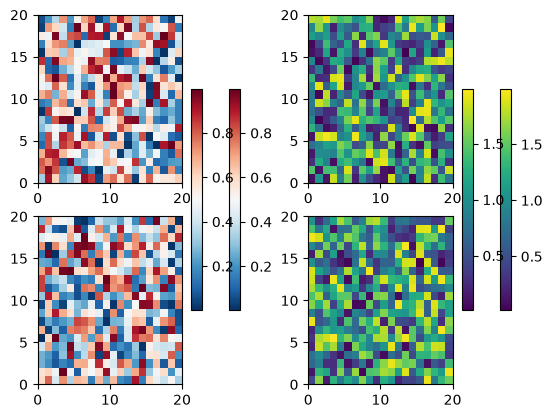

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2,2)
cmaps=['RdBu_r', 'viridis']
for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(np.random.random((20, 20)) * (col + 1),
                            cmap=cmaps[col])
        fig.colorbar(pcm, ax=axs[:, col], shrink=0.6)
        

The stolen space can lead to Axes in the same subplot layout being different sizes, which is often undesired if the the x-axis on each plot is meant to be comparable as in the following:

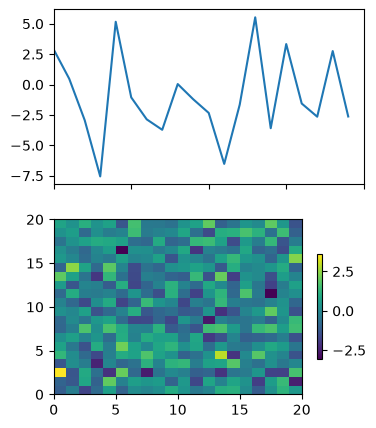

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=True)
X = np.random.randn(20, 20)
axs[0].plot(np.sum(X, axis=0))
pcm= axs[1].pcolormesh(X)
fig.colorbar(pcm, ax=axs[1], shrink = 0.6)

This is usually undesired, and can be worked around in various ways, e.g. adding a colorbar to the other Axes and then removing it. However, the most straightforward is to use constrained layout:

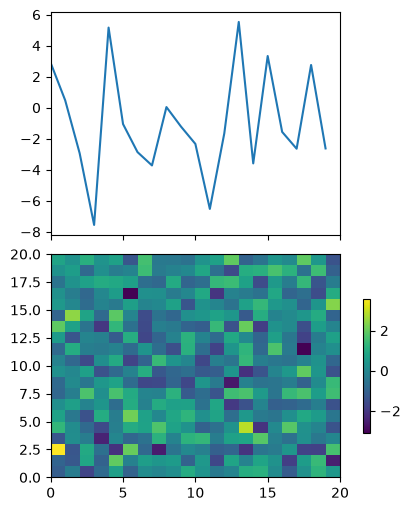

In [5]:
fig, axs = plt.subplots(2,1,figsize=(4,5), sharex=True, layout='constrained')
axs[0].plot(np.sum(X, axis=0))
pcm = axs[1].pcolormesh(X)
fig.colorbar(pcm, ax=axs[1], shrink=0.6)

Relatively complicated colorbar layouts are possible using this paradigm. Note that this example works far better with layout='constrained'

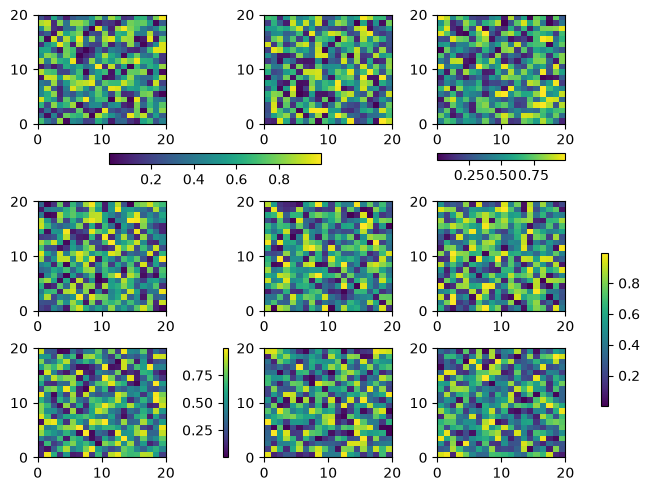

In [6]:
fig, axs = plt.subplots(3,3, layout='constrained')
for ax in axs.flat:
    pcm = ax.pcolormesh(np.random.random((20, 20)))

fig.colorbar(pcm, ax=axs[0, :2], shrink = 0.6, location ='bottom')
fig.colorbar(pcm, ax=axs[0, 2], location ='bottom')
fig.colorbar(pcm, ax=axs[1:, :], shrink = 0.6, location ='right')
fig.colorbar(pcm, ax=axs[2, 1], location ='left')

<h2>Adjusting the spacing between colorbars and parent Axes</h2>

The distance a colorbar is from the parent Axes can be adjusted with the pad keyword argument. This is in units of fraction of the parent Axes width, and the default for a vertical Axes is 0.05 (or 0.15 for a horizontal Axes).

Text(0.5, 0.98, "layout='constrained'")

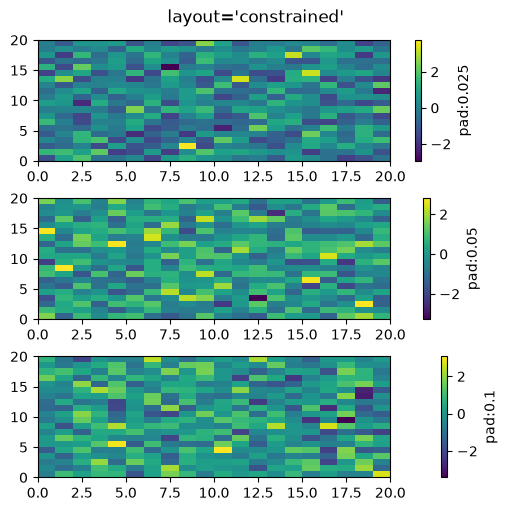

In [10]:
fig, axs = plt.subplots(3, 1, layout='constrained', figsize=(5,5))
for ax, pad in zip(axs, [0.025, 0.05, 0.1]):
    pcm = ax.pcolormesh(np.random.randn(20, 20), cmap='viridis')
    fig.colorbar(pcm,ax=ax,pad=pad,label=f'pad:{pad}')
fig.suptitle("layout='constrained'")



Note that if you do not use constrained layout, the pad command makes the parent Axes shrink:

Text(0.5, 0.98, 'No layout manager')

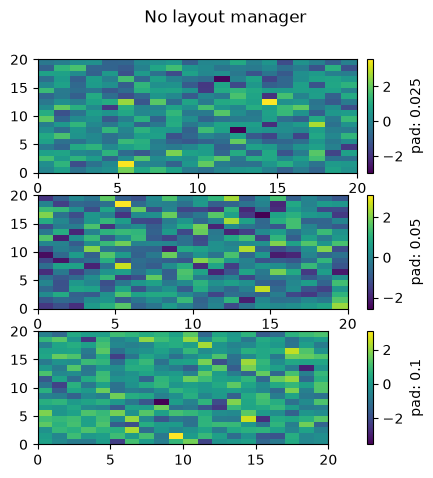

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(5, 5))
for ax, pad in zip(axs, [0.025, 0.05, 0.1]):
    pcm = ax.pcolormesh(np.random.randn(20, 20), cmap='viridis')
    fig.colorbar(pcm, ax=ax, pad=pad, label=f'pad: {pad}')
fig.suptitle("No layout manager")

<h2>Manual placement of colorbars</h2>

Sometimes the automatic placement provided by colorbar does not give the desired effect. We can manually create an Axes and tell colorbar to use that Axes by passing the Axes to the cax keyword argument.

<h4>Using inset_axes</h4>
We can manually create any type of Axes for the colorbar to use, but an Axes.inset_axes is useful because it is a child of the parent Axes and can be positioned relative to the parent. Here we add a colorbar centered near the bottom of the parent Axes.


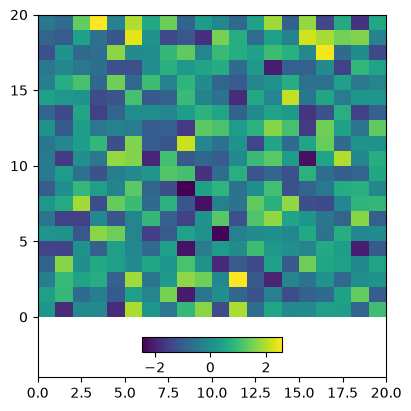

In [13]:
fig, ax = plt.subplots(layout='constrained', figsize=(4,4))
pcm = ax.pcolormesh(np.random.randn(20,20), cmap='viridis')
ax.set_ylim([-4, 20])
cax = ax.inset_axes([0.3, 0.07,0.4, 0.04])
fig.colorbar(pcm, cax=cax, orientation='horizontal')

<h2>Colorbars attached to fixed-aspect-ration Axes</h2>
Axes with a fixed aspect ratio may shrink in height to preserve the aspect ratio of the underlying data. This can result in the colorbar becoming taller than the associated Axes, as demonstrated in the following example.

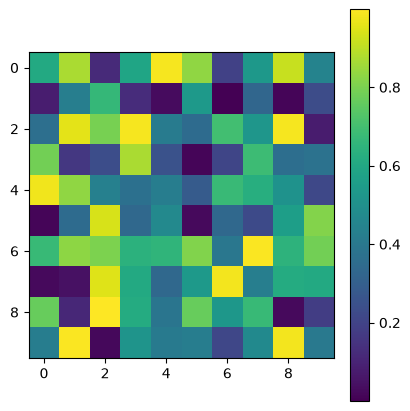

In [15]:
fig, ax = plt.subplots(layout='constrained', figsize=(4,4))
pcm = ax.imshow(np.random.rand(10,10), cmap='viridis')
fig.colorbar(pcm, ax=ax)

To automatically adjust the colorbar size to match the parent Axes, we can use layout='compressed'. This ensures that as the figure is resized or the fixed-aspect-ratio Axes is zoomed in or out, the colorbar dynamically resizes to align with the parent Axes.

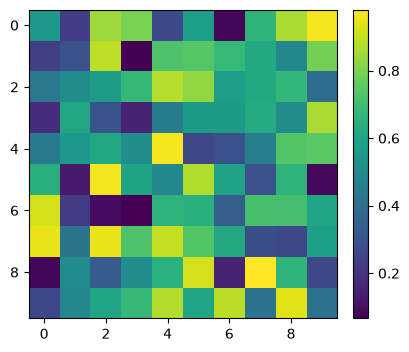

In [17]:
fig, ax = plt.subplots(layout='compressed', figsize=(4,4))
pcm = ax.imshow(np.random.rand(10,10), cmap='viridis')
fig.colorbar(pcm, ax=ax)

Alternatively, we can manually position the colorbar using Axes.inset_axes with axes-relative coordinates. This approach provides precise control over the colorbar's placement. However, without a layout engine, the colorbar might be clipped if it extends beyond the figure boundaries.

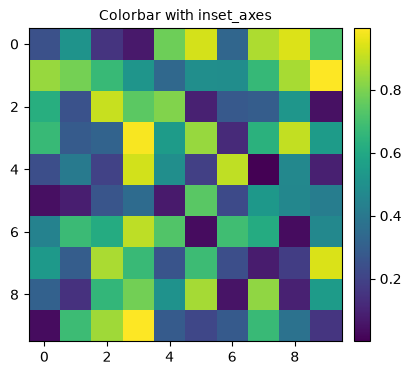

In [19]:
fig, ax = plt.subplots(figsize=(4,4), layout='constrained')
pcm = ax.imshow(np.random.rand(10,10), cmap='viridis')
cax = ax.inset_axes([1.04, 0.0, 0.05, 1.0]) #positioning the colorbar
ax.set_title('Colorbar with inset_axes', fontsize='medium')
fig.colorbar(pcm, cax=cax)

We can also do this manually using an Axes.inset_axes using axes-relative coordinates (see Transformations Tutorial). Note that if we do not use a layout engine, the colorbar will be clipped off the right side of the figure.

In [ ]:
fig, ax = plt.subplots(layout='constrained', figsize=(4,4))
pcm = ax.imshow(np.random.randn(10,10), cmap='viridis')
cax = ax.inset_axes([1.04, 0.0, 0.05, 1.0])
ax.set_title('Colorbar with inset_axes', fontsize='medium' )